**Assignment 1: Single Layer Perceptron**

## 1. Import Library dan Membaca Spreadsheet

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


data = pd.read_csv(
    "/content/iris.csv",
    header=None
)

print(data.shape)
print(data.head())
print(data.columns)

data.columns = [
    "X1",
    "X2",
    "X3",
    "X4",
    "Species"
]


(100, 5)
     0    1    2    3            4
0  5.1  3.5  1.4  0.2  Iris-setosa
1  4.9  3.0  1.4  0.2  Iris-setosa
2  4.7  3.2  1.3  0.2  Iris-setosa
3  4.6  3.1  1.5  0.2  Iris-setosa
4  5.0  3.6  1.4  0.2  Iris-setosa
Index([0, 1, 2, 3, 4], dtype='int64')


## 2. Menyiapkan Data dan Parameter Model

In [55]:

LEARNING_RATE = 0.1
EPOCHS = 5
INITIAL_BIAS = 0.5
INITIAL_THETA = np.array([0.5, 0.5, 0.5, 0.5], dtype=float)
THRESHOLD = 0.5


data["Target"] = data["Species"].map({
    "Iris-setosa": 0,
    "Iris-versicolor": 1
})

setosa = data[data["Target"] == 0].reset_index(drop=True)
versicolor = data[data["Target"] == 1].reset_index(drop=True)

train_data = pd.concat([
    setosa.iloc[:40],
    versicolor.iloc[:40]
]).reset_index(drop=True)

validation_data = pd.concat([
    setosa.iloc[40:],
    versicolor.iloc[40:]
]).reset_index(drop=True)

features = ["X1", "X2", "X3", "X4"]

X_train = train_data[features].to_numpy(dtype=float)
y_train = train_data["Target"].to_numpy(dtype=float)

X_validation = validation_data[features].to_numpy(dtype=float)
y_validation = validation_data["Target"].to_numpy(dtype=float)



print("Training data   :", X_train.shape)
print("Validation data :", X_validation.shape)

Training data   : (80, 4)
Validation data : (20, 4)


## 3. Mendefinisikan Fungsi Single Layer Perceptron

In [56]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


def predict_class(output):
    return 1 if output > THRESHOLD else 0


def calculate_gradient(output, target, x):
    error = output - target

    sigmoid_derivative = (
        output * (1 - output)
    )

    dbias = (
        2
        * error
        * sigmoid_derivative
    )

    dtheta = (
        dbias * x
    )

    return dbias, dtheta
def calculate_z(bias, theta, x):
    return bias + np.dot(theta, x)

def calculate_error(output, target):
    return output - target

## 4. Training Single Layer Perceptron

In [57]:
def train_slp(
    X,
    y,
    epochs,
    learning_rate,
    initial_bias,
    initial_theta
):

    bias = float(initial_bias)
    theta = initial_theta.copy().astype(float)

    history = []
    validation_weights = []


    for epoch in range(1, epochs + 1):

        losses = []
        predictions = []


        for i in range(len(X)):

            x = X[i]
            target = y[i]


            z = calculate_z(bias, theta, x)
            output = sigmoid(z)

            prediction = predict_class(output)

            error = calculate_error(output, target)
            loss = error ** 2

            dbias, dtheta = calculate_gradient(
                output,
                target,
                x
            )

            losses.append(loss)
            predictions.append(prediction)

            bias -= learning_rate * dbias
            theta -= learning_rate *dtheta

            if i == len(X) - 1:
                validation_weights.append({
                    "epoch": epoch,
                    "bias": bias,
                    "theta": theta.copy()
                })



        predictions = np.array(predictions)

        mse = np.mean(losses)

        accuracy = np.mean(
            predictions == y
        )

        history.append({
            "Epoch": epoch,
            "MSE": mse,
            "Accuracy": accuracy
        })


    return (
        pd.DataFrame(history),
        validation_weights
    )


training_summary, validation_weights = train_slp(
    X=X_train,
    y=y_train,
    epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
    initial_bias=INITIAL_BIAS,
    initial_theta=INITIAL_THETA
)

display(training_summary)

,Epoch,MSE,Accuracy
0,1,0.449889,0.5250
1,2,0.037452,0.9500
2,3,0.024372,0.9750
3,4,0.017357,0.9750
4,5,0.012740,0.9875


## 5. Validation Single Layer Perceptron

In [58]:
def validate_slp(
    X,
    y,
    validation_weights,
):

    history = []


    for weight_info in validation_weights:

        epoch = weight_info["epoch"]

        bias = float(
            weight_info["bias"]
        )

        theta = (
            weight_info["theta"]
            .copy()
            .astype(float)
        )

        losses = []
        predictions = []


        for i in range(len(X)):

            x = X[i]
            target = y[i]

            z = calculate_z(bias, theta, x)
            output = sigmoid(z)

            prediction = predict_class(output)


            error = calculate_error(output, target)
            loss = error ** 2

            losses.append(loss)
            predictions.append(prediction)


        predictions = np.array(predictions)

        mse = np.mean(losses)

        accuracy = np.mean(
            predictions == y
        )

        history.append({
            "Epoch": epoch,
            "MSE": mse,
            "Accuracy": accuracy
        })


    return pd.DataFrame(history)


validation_summary = validate_slp(
    X=X_validation,
    y=y_validation,
    validation_weights=validation_weights,
)

display(validation_summary)

,Epoch,MSE,Accuracy
0,1,0.328951,0.50
1,2,0.247289,0.50
2,3,0.175892,0.50
3,4,0.119381,0.85
4,5,0.081581,1.00


## 6. Hasil, Visualisasi, dan Validasi

,Epoch,Training MSE,Validation MSE,Training Accuracy,Validation Accuracy
0,1,0.449889,0.328951,0.5250,0.50
1,2,0.037452,0.247289,0.9500,0.50
2,3,0.024372,0.175892,0.9750,0.50
3,4,0.017357,0.119381,0.9750,0.85
4,5,0.012740,0.081581,0.9875,1.00


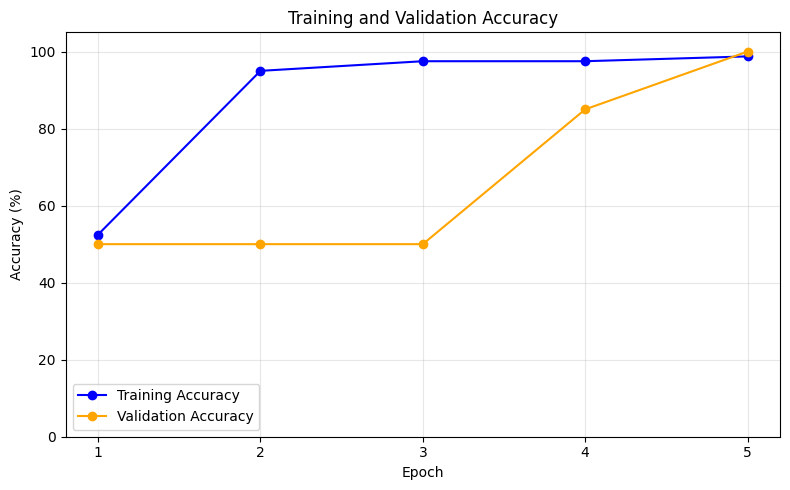

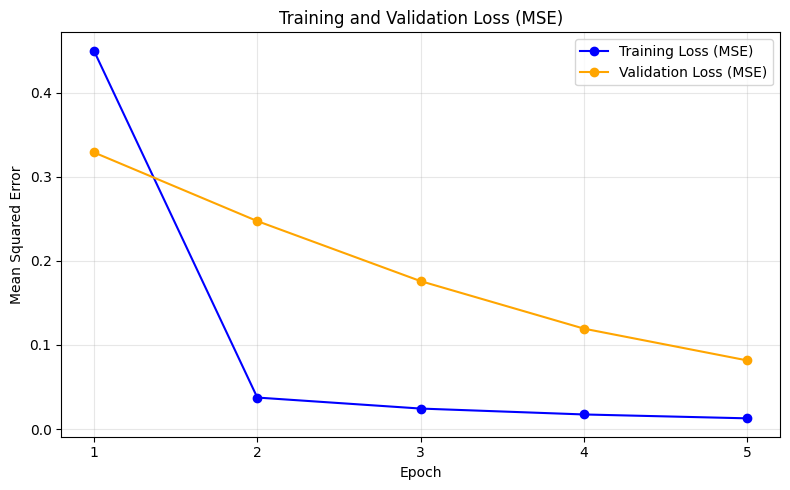

=== VALIDASI DENGAN SPREADSHEET ===


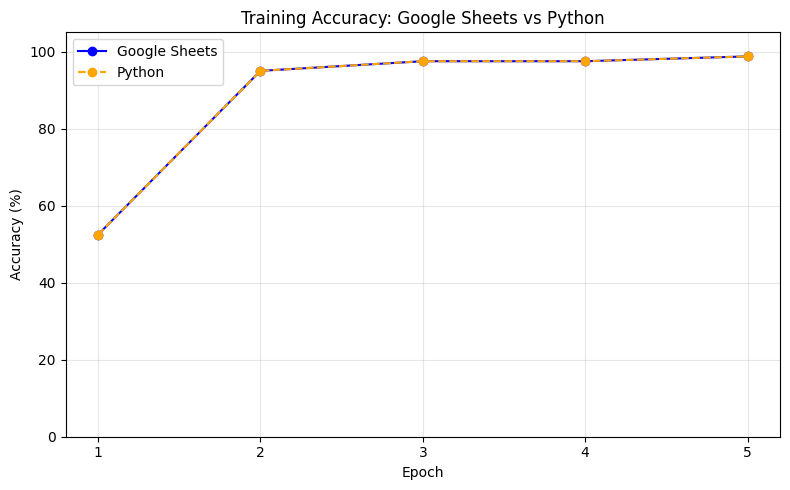

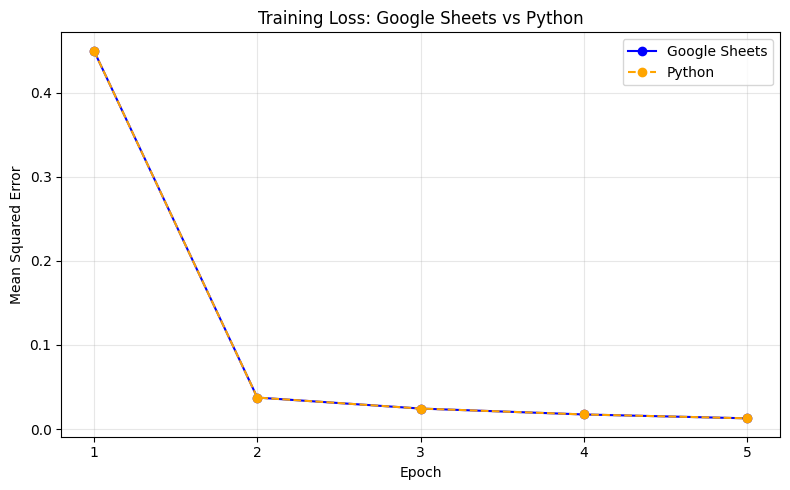

In [59]:


result = pd.DataFrame({
    "Epoch": training_summary["Epoch"],
    "Training MSE": training_summary["MSE"],
    "Validation MSE": validation_summary["MSE"],
    "Training Accuracy": training_summary["Accuracy"],
    "Validation Accuracy": validation_summary["Accuracy"]
})

display(result)




plt.figure(figsize=(8, 5))

plt.plot(
    result["Epoch"],
    result["Training Accuracy"] * 100,
    marker="o",
    color="blue",
    label="Training Accuracy",
)

plt.plot(
    result["Epoch"],
    result["Validation Accuracy"] * 100,
    marker="o",
    color="orange",
    label="Validation Accuracy"
)


plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.xticks(result["Epoch"])
plt.ylim(0, 105)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))

plt.plot(
    result["Epoch"],
    result["Training MSE"],
    marker="o",
    color="blue",
    label="Training Loss (MSE)"
)

plt.plot(
    result["Epoch"],
    result["Validation MSE"],
    marker="o",
    color="orange",
    label="Validation Loss (MSE)"
)

plt.title("Training and Validation Loss (MSE)")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.xticks(result["Epoch"])
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()



sheet_training_mse = np.array([
    0.4498886551,
    0.03745191423,
    0.024372195,
    0.01735720168,
    0.01274015821
])

sheet_training_accuracy = np.array([
    0.525,
    0.95,
    0.975,
    0.975,
    0.9875
])

sheet_validation_mse = np.array([
    0.3289511566,
    0.2472893233,
    0.1758916407,
    0.1193813733,
    0.08158136941
])

sheet_validation_accuracy = np.array([
    0.5,
    0.5,
    0.5,
    0.85,
    1.00
])


print("=== VALIDASI DENGAN SPREADSHEET ===")



plt.figure(figsize=(8, 5))

plt.plot(
    training_summary["Epoch"],
    sheet_training_accuracy * 100,
    marker="o",
    color="blue",
    label="Google Sheets"
)

plt.plot(
    training_summary["Epoch"],
    training_summary["Accuracy"] * 100,
    marker="o",
    color="orange",
    linestyle="--",
    label="Python"
)

plt.title("Training Accuracy: Google Sheets vs Python")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.xticks(training_summary["Epoch"])
plt.ylim(0, 105)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()



plt.figure(figsize=(8,5))

plt.plot(
    training_summary["Epoch"],
    sheet_training_mse,
    marker="o",
    color="blue",
    label="Google Sheets"
)

plt.plot(
    training_summary["Epoch"],
    training_summary["MSE"],
    marker="o",
    color="orange",
    linestyle="--",
    label="Python"
)

plt.title("Training Loss: Google Sheets vs Python")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.xticks(training_summary["Epoch"])
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()